# NumPy Basics: Arrays and Vectorized Computation

## The NumPy ndarray: A Multidimensional Array Object Continued

### Boolean Indexing

In [18]:
import numpy as np
# dengan boolean indexing, kita bisa memilih elemen array berdasarkan kondisi tertentu
# misal kita punya 2 array
names = np.array(['Alice', 'Bob', 'Charlie', 'David', "Bob", "David", "David"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2],[-12, -4], [3, 4]])
print("array names:")
print(names)
print("\narray data:")
print(data)

# mari kita mainkan operasi boolean indexing
# misal dimana saja nama bob muncul?
bob_mask = (names == 'Bob') # membuat mask boolean untuk nama bob
print("\nmask boolean untuk nama bob:")
print(bob_mask)
# kita juga bisa menggunakan indez untuk mengakses data yang sesuai dengan mask boolean
print("\ndata yang sesuai dengan mask boolean untuk nama bob:")
print(data[bob_mask]) # mengakses data yang sesuai dengan mask boolean untuk nama bob
# perlu diinginat untuk operasinya ini kedua array harus memiliki shape yang sama, jika tidak maka akan error

print("\ndata yang sesuai dengan mask boolean untuk nama bob (kolom kedua saja):")
print(data[names == "Bob", 1:])

array names:
['Alice' 'Bob' 'Charlie' 'David' 'Bob' 'David' 'David']

array data:
[[  4   7]
 [  0   2]
 [ -5   6]
 [  0   0]
 [  1   2]
 [-12  -4]
 [  3   4]]

mask boolean untuk nama bob:
[False  True False False  True False False]

data yang sesuai dengan mask boolean untuk nama bob:
[[0 2]
 [1 2]]

data yang sesuai dengan mask boolean untuk nama bob (kolom kedua saja):
[[2]
 [2]]


In [19]:

# untuk mask selain nama bob, kita gunakan !=
print("mask boolean untuk nama bukan bob:")
print(names != "Bob") # membuat mask boolean untuk nama bukan bob
print("data yang sesuai dengan mask boolean untuk nama bukan bob:")
print(data[names != "Bob"]) # mengakses data yang sesuai dengan mask boolean untuk nama bukan bob
# atau kita bisa gunakan negasi(~) untuk membalikkan mask boolean
print("data yang sesuai dengan mask boolean untuk nama bukan bob (menggunakan negasi):")
print(data[~(names == "Bob")]) # mengakses data yang sesuai dengan mask boolean untuk nama bukan bob
print("data yang sesuai dengan mask boolean untuk nama bukan bob (menggunakan negasi dan kolom kedua saja):")
print(data[~(names == "Bob"), 1:]) # mengakses data yang sesuai dengan mask boolean untuk nama bukan bob dan kolom kedua saja

# perlu diingat, dengan numpy keyword and dan or tidak bisa digunakan untuk operasi boolean indexing
# mereka diganti dengan & dan |, tetapi harus menggunakan tanda kurung untuk mengelompokkan kondisi
# misal kita ingin mengakses data yang sesuai dengan nama bob dan kolom kedua lebih besar dari 1
print("data yang sesuai dengan nama bob dan kolom kedua lebih besar dari 1:")
print(data[(names == "Bob") & (data[:, 1] > 1)]) # mengakses data yang sesuai dengan nama bob dan kolom kedua lebih besar dari 1
#atau nama charlie atau bob
print("data yang sesuai dengan nama charlie atau bob:")
print(data[(names == "Charlie") | (names == "Bob")]) # mengakses data yang sesuai dengan nama charlie atau bob

mask boolean untuk nama bukan bob:
[ True False  True  True False  True  True]
data yang sesuai dengan mask boolean untuk nama bukan bob:
[[  4   7]
 [ -5   6]
 [  0   0]
 [-12  -4]
 [  3   4]]
data yang sesuai dengan mask boolean untuk nama bukan bob (menggunakan negasi):
[[  4   7]
 [ -5   6]
 [  0   0]
 [-12  -4]
 [  3   4]]
data yang sesuai dengan mask boolean untuk nama bukan bob (menggunakan negasi dan kolom kedua saja):
[[ 7]
 [ 6]
 [ 0]
 [-4]
 [ 4]]
data yang sesuai dengan nama bob dan kolom kedua lebih besar dari 1:
[[0 2]
 [1 2]]
data yang sesuai dengan nama charlie atau bob:
[[ 0  2]
 [-5  6]
 [ 1  2]]


In [20]:
# untuk mengubah suatu value pada array, kita bisa menggunakan operasi boolean masking untuk mengakses elemen yang sesuai
# lalu kita bisa mengubah value tersebut dengan assignment

# misal di dalam data, angka negatif kita ubah jadi nol
data[data < 0] = 0
print("data setelah angka negatif diubah menjadi nol:")
print(data)

# atau kita mengatur keseluruhan baris atau kolum dengan boolean array 1 dimensi
data[names != "Charlie"] = 7
print("data setelah baris dengan nama bukan Charlie diubah menjadi 7:")
print(data)

data setelah angka negatif diubah menjadi nol:
[[4 7]
 [0 2]
 [0 6]
 [0 0]
 [1 2]
 [0 0]
 [3 4]]
data setelah baris dengan nama bukan Charlie diubah menjadi 7:
[[7 7]
 [7 7]
 [0 6]
 [7 7]
 [7 7]
 [7 7]
 [7 7]]


### Fancy Indexing

In [28]:
# Fancy Indexing adalah teknik indexing menggunakan array integer
# Dengan ini kita bisa mengambil banyak elemen spesifik sekaligus secara acak, tidak harus berurutan
# Fancy Indexing memiliki 2 karakteristik:
# 1. Mengembalikan salinan data, bukan view
# 2. membentuk array baru dengan shape yang sama dengan array index yang digunakan

# mari kita coba dengan contoh sederhana, kita buat array 1 dimensi
arr = np.zeros(10)
for i in range(10):
    arr[i] = i
print("array arr:")
print(arr)

# misal kita ingin mengambil elemen 2,4,6,8 dari array dengan urutan tersebut
arr_index = arr[[2, 4, 6, 8]] # menggunakan fancy indexing dengan array integer
print("array arr dengan fancy indexing:")
print(arr_index) # mengembalikan array baru dengan shape yang sama dengan array index yang digunakan
# bila kita menggunakan negative index, maka akan mengambil elemen dari belakang
arr_index_neg = arr[[-1, -3, -5, -7]] # menggunakan fancy indexing dengan array integer negative index
print("array arr dengan fancy indexing negative index:")
print(arr_index_neg)

# bila multidimensi, misal 2d
arr2d = np.zeros((10,6))
for i in range(10):
    arr2d[i] = i
print("array 2D arr2d:")
print(arr2d)

# misal kita ingin mengambil elemen 4,3,0,7 dari array 2D dengan urutan tersebut
arr2d_index = arr2d[[4, 3, 0, 7]]
print("array 2D arr2d dengan fancy indexing:")
print(arr2d_index)
# bila index negative, maka akan mengambil elemen dari belakang
arr2d_index_neg = arr2d[[-1, -3, -5, -7]]
print("array 2D arr2d dengan fancy indexing negative index:")
print(arr2d_index_neg)
# bila kita menggunakan multiple index array, maka akan sesuai baris dan kolom yang diinginkan, tetapi index dimulai dari 0
arr = np.arange(32).reshape((8, 4))
print("array arr:")
print(arr)
# misal kita ingin mengambil elemen: [[1, 0], [5, 3], [7, 1], [2, 2]]
multi_index = arr[[1,5,7,2],[0,3,1,2]] # menggunakan fancy indexing dengan multiple index array
print("array arr dengan fancy indexing multiple index:")
print(multi_index) # mengembalikan array baru dengan shape yang sama dengan array index yang digunakan

multi_index_matrix = arr[[1,5,7,2]][:,[0,3,1,2]] # menggunakan fancy indexing dengan multiple index array
print("array arr dengan fancy indexing multiple index matrix:")
print(multi_index_matrix) # mengembalikan array baru dengan shape yang sama dengan array index yang digunakan

array arr:
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
array arr dengan fancy indexing:
[2. 4. 6. 8.]
array arr dengan fancy indexing negative index:
[9. 7. 5. 3.]
array 2D arr2d:
[[0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4. 4.]
 [5. 5. 5. 5. 5. 5.]
 [6. 6. 6. 6. 6. 6.]
 [7. 7. 7. 7. 7. 7.]
 [8. 8. 8. 8. 8. 8.]
 [9. 9. 9. 9. 9. 9.]]
array 2D arr2d dengan fancy indexing:
[[4. 4. 4. 4. 4. 4.]
 [3. 3. 3. 3. 3. 3.]
 [0. 0. 0. 0. 0. 0.]
 [7. 7. 7. 7. 7. 7.]]
array 2D arr2d dengan fancy indexing negative index:
[[9. 9. 9. 9. 9. 9.]
 [7. 7. 7. 7. 7. 7.]
 [5. 5. 5. 5. 5. 5.]
 [3. 3. 3. 3. 3. 3.]]
array arr:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]
array arr dengan fancy indexing multiple index:
[ 4 23 29 10]
array arr dengan fancy indexing multiple index matrix:
[[ 4  7  5  6]
 [20 23 21 22]
 [28 31 29 30]
 [ 8 11  9 10]]


### Transposing Arrays and Swapping Axes

In [ ]:
# mentraspose array adalah operasi untuk menukar baris dan kolom pada array(bilang 2D) atau menukar axis pada array (bilang lebih dari 2D)
# misal kita punya array 2D
arr = np.arange(20).reshape((4,5))
print("array arr:")
print(arr)

# bila ingin mentranspose array, kita bisa menggunakan method .T
arr_transpose = arr.T
print("array arr setelah ditranspose:") 
print(arr_transpose)

# ini sering digunakan untuk operasi matriks
# misal
arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]]) # suatu array 5x3(2d)
print("array arr:")
print(arr)
# kita ingin mencari dot product dari arr dengan transpose arr
arr_dot = np.dot(arr.T, arr) # dot product dari transpose arr dengan arr
print("array arr_dot:")
print(arr_dot)
# atau perkalian matriks dengan menggunakan operator @
arr_dot2 = arr.T @ arr # dot product dari transpose arr dengan arr
print("array arr_dot2:")
print(arr_dot2)
# ada spesial case untuk transpose, yaitu swap axes, yaitu menukar axis tertentu pada array multidimensi
# misal kita punya array 3D
arr.swapaxes(0, 1) # menukar axis 0 dan 1 pada array arr, ingat ini view, bukan salinan
print("array arr setelah swap axes 0 dan 1:")
print(arr.swapaxes(0, 1)) #hasilnya sama dengan transpose, karena array 2D hanya memiliki 2 axis, yaitu axis 0 dan 1

array arr:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
array arr setelah ditranspose:
[[ 0  5 10 15]
 [ 1  6 11 16]
 [ 2  7 12 17]
 [ 3  8 13 18]
 [ 4  9 14 19]]
array arr:
[[ 0  1  0]
 [ 1  2 -2]
 [ 6  3  2]
 [-1  0 -1]
 [ 1  0  1]]
array arr_dot:
[[39 20 12]
 [20 14  2]
 [12  2 10]]
array arr_dot2:
[[39 20 12]
 [20 14  2]
 [12  2 10]]
array arr setelah swap axes 0 dan 1:
[[ 0  1  6 -1  1]
 [ 1  2  3  0  0]
 [ 0 -2  2 -1  1]]


## Pseudorandom Number Generation

In [ ]:
# numpy.random modul menghasilkan bilangan acak, mendukung built-in python random,menghasilkan:
# baik bilangan acak float maupun integer
# dan juga bisa menghasilkan bilangan acak dari distribusi tertentu
# tetapi modul ini pseurando, artinya ke random an dihasil dari algoritma tertentu(berupa seed), sehingga bisa direproduksi

# misal kita ingin membuat array 5x5 dengan nilai distribusi standar normal
samples = np.random.standard_normal(size=(5, 5)) # menghasilkan array 5x5 dengan nilai distribusi standar normal
print("array samples:")
print(samples)

array samples:
[[-1.47432171e+00  3.21387946e-01 -2.39641693e-01  6.49395336e-02
   2.58371090e-03]
 [-1.38346134e+00  3.80968302e-01  4.92307553e-01  1.04873315e-01
   2.42676411e-02]
 [ 2.06120810e-02  1.81063585e+00  1.75693707e+00  1.11727615e+00
  -3.78848517e-01]
 [ 1.02516122e+00  7.59456262e-01 -4.70778659e-01  2.71489207e+00
  -4.78378747e-01]
 [ 1.46200194e+00  1.69210513e+00  9.66185019e-01 -9.34012436e-01
  -6.52883070e-01]]


### berikut metode yang bisa digunakan untuk menghasilkan bilangan acak dengan numpy.random
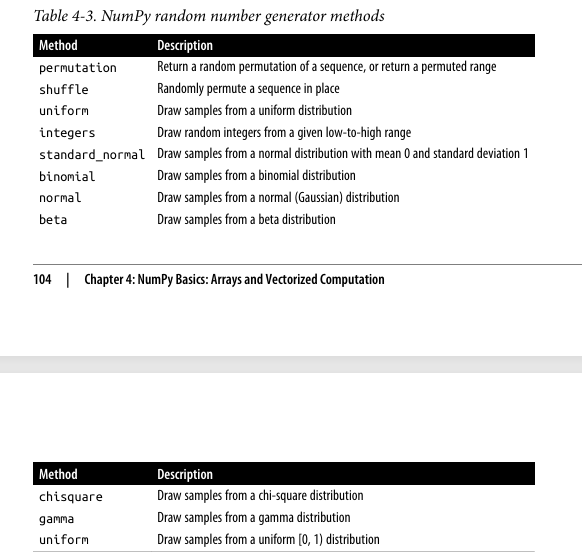

## Universal Functions: Fast Element-Wise Array Functions

### Dengan ufuncs, kita bisa melakukan operasi tiap elemen pada array tanpa loop

In [42]:
# misal kita punya array
arr = np.arange(16)
print("array arr:")
print(arr)

# kita ingin mencari akar kuadrat tiap elemen
sqrt_arr = np.sqrt(arr) # mencari akar kuadrat tiap elemen array arr
print("array sqrt_arr:")
print(sqrt_arr)

# atau kita ingin mencari nilai eksponensial tiap elemen
exp_arr = np.exp(arr) # mencari nilai eksponensial tiap elemen array arr
print("array exp_arr:")
print(exp_arr)

# kedua fungsi diatas adalah unary ufuncs, yaitu fungsi yang hanya membutuhkan 1 input array
# ada yang perlu 2 input array, yaitu binary ufuncs, misal kita punya 2 array
rng = np.random.default_rng(seed=12345) # membuat random number generator
x = rng.standard_normal(10) # membuat array 1D dengan 10 elemen dari distribusi standar normal
y = rng.standard_normal(10) # membuat array 1D dengan 10 elemen dari distribusi standar normal
print("array x:")
print(x)
print("array y:")
print(y)

# misal kita ingin mencari nilai maksimum tiap elemen dari kedua array
max_arr = np.maximum(x, y) # mencari nilai maksimum tiap elemen dari kedua array x dan y
print("array max_arr:")
print(max_arr)

array arr:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
array sqrt_arr:
[0.         1.         1.41421356 1.73205081 2.         2.23606798
 2.44948974 2.64575131 2.82842712 3.         3.16227766 3.31662479
 3.46410162 3.60555128 3.74165739 3.87298335]
array exp_arr:
[1.00000000e+00 2.71828183e+00 7.38905610e+00 2.00855369e+01
 5.45981500e+01 1.48413159e+02 4.03428793e+02 1.09663316e+03
 2.98095799e+03 8.10308393e+03 2.20264658e+04 5.98741417e+04
 1.62754791e+05 4.42413392e+05 1.20260428e+06 3.26901737e+06]
array x:
[-1.42382504  1.26372846 -0.87066174 -0.25917323 -0.07534331 -0.74088465
 -1.3677927   0.6488928   0.36105811 -1.95286306]
array y:
[ 2.34740965  0.96849691 -0.75938718  0.90219827 -0.46695317 -0.06068952
  0.78884434 -1.25666813  0.57585751  1.39897899]
array max_arr:
[ 2.34740965  1.26372846 -0.75938718  0.90219827 -0.07534331 -0.06068952
  0.78884434  0.6488928   0.57585751  1.39897899]


#### berikut list ufuncs yang bisa digunakan pada numpy
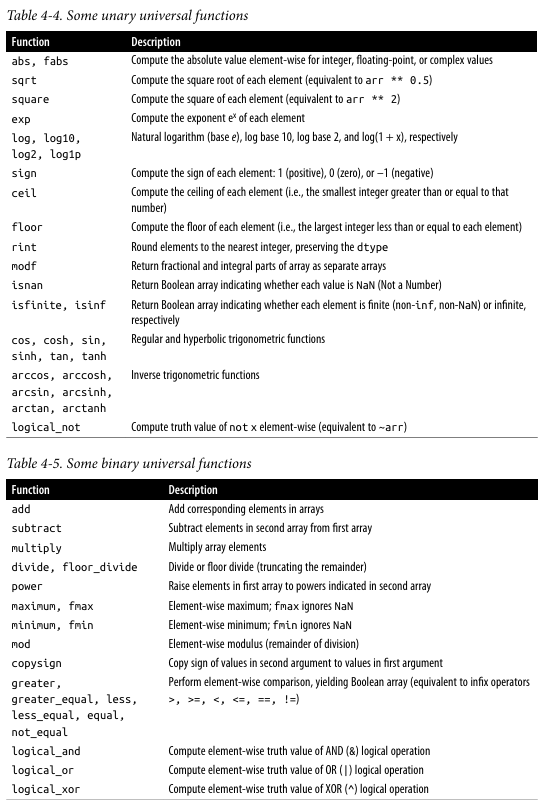

## Array-Oriented Programming with Arrays

### dengan array oriented programming, kita menganti loop eksplisit dengan operasi array, sehingga lebih cepat dan efisien 10-100x

In [43]:
# misal dengan meshgrid, kita bisa membuat grid 2D dari dua array 1D
points = np.arange(-5, 5, 0.01) # membuat array 1D dari -5 sampai 5 dengan step 0.01(100 titik)
xs, ys = np.meshgrid(points, points) # membuat grid 2D dari array points
z = np.sqrt(xs**2 + ys**2) # menghitung jarak dari titik (0,0) ke setiap titik pada grid
print("jarak dari titik (0,0) ke setiap titik pada grid 100 x 100:")
print(z)

jarak dari titik (0,0) ke setiap titik pada grid 100 x 100:
[[7.07106781 7.06400028 7.05693985 ... 7.04988652 7.05693985 7.06400028]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 ...
 [7.04988652 7.04279774 7.03571603 ... 7.0286414  7.03571603 7.04279774]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]]


### Expressing Conditional Logic as Array Operations

In [44]:
# kita bisa menggunakan numpy.where untuk mengekspresikan logika kondisional sebagai operasi array
# misal kita punya 2 array 1D
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, False, True])
# kita ingin mengambil elemen xarr jika cond=true, dan elemen yarr jika cond=false
result=np.where(cond, xarr, yarr) # where(berdasarkan kondisi, ambil dari xarr jika True, ambil dari yarr jika False)
# atau kita ingin mengganti semua nilai positif pada array dengan 1
arr = rng.standard_normal((5, 5)) # membuat array 5x5 dengan nilai distribusi standar normal
print("array arr:")
print(arr)
# kita gunakan where untuk mengganti semua nilai positif pada array dengan 1
postif_to_one = np.where(arr > 0, 1, arr) # where(berdasarkan kondisi, jadikan 1 jika True, gunakan arr jika False)

array arr:
[[ 1.32229806 -0.29969852  0.90291934 -1.62158273 -0.15818926]
 [ 0.44948393 -1.34360107 -0.08168759  1.72473993  2.61815943]
 [ 0.77736134  0.8286332  -0.95898831 -1.20938829 -1.41229201]
 [ 0.54154683  0.7519394  -0.65876032 -1.22867499  0.25755777]
 [ 0.31290292 -0.13081169  1.26998312 -0.09296246 -0.06615089]]


### Mathematical and Statistical Methods

In [56]:
# yang pertama ada agregasi dasar(reduksi) terdiri dari: sum, mean, std, var, min, max
# misal kita punya array 2D
arr = rng.standard_normal((7, 6)) # membuat array 7x6 dengan nilai distribusi standar normal
print("array arr:")
print(arr)

#kita cari sum
sum_arr = arr.sum() # mencari sum dari array arr
print("sum dari array arr:")
print(sum_arr)

# kita cari mean
mean_arr = arr.mean() # mencari mean dari array arr
print("mean dari array arr:")
print(mean_arr)

# standar deviasi(std)
std_arr = arr.std() # mencari standar deviasi dari array arr
print("standar deviasi dari array arr:")
print(std_arr)

#variansi
var_arr = arr.var() # mencari variansi dari array arr
print("variansi dari array arr:")
print(var_arr)

# dengan argument axis, kita bisa melakukan agregasi pada axis tertentu(axis=0 untuk kolom, axis=1 untuk baris)
# mencari sum pada axis=0(kolom)
sum_arr_axis0 = arr.sum(axis=0) # mencari sum pada tiap axis=0(kolom)
print("sum dari array arr pada axis=0(kolom):")
print(sum_arr_axis0)

array arr:
[[-1.64844862 -0.34108647 -0.12419497  0.11691574  2.3612187   1.55516878]
 [-1.0298594   2.15940445 -1.19253343 -1.8708905  -1.49848205  0.20345047]
 [ 0.53486059 -2.21108587  0.43597419 -0.26705217  0.70638953 -0.38460681]
 [ 0.90008171  0.56434513 -1.17264499  1.445592    0.21242713  0.73004882]
 [ 1.26177194 -0.97475833 -0.08473721 -0.82169797 -0.94237273  0.26597955]
 [ 0.33979111  1.33140349  1.38554064 -0.0213583  -0.83706473  3.20068942]
 [ 2.14788244 -0.10666477 -0.93015494 -0.42367437  0.28096105  1.13155122]]
sum dari array arr:
6.388079433661426
mean dari array arr:
0.1520971293728911
standar deviasi dari array arr:
1.1956107264422688
variansi dari array arr:
1.4294850091838096
sum dari array arr pada axis=0(kolom):
[ 2.50607975  0.42155763 -1.68275071 -1.84216558  0.2830769   6.70228144]


In [57]:
# ada juga mencari nilai yang membuat minimum dan maksimum, yaitu argmin dan argmax
argmin_arr = arr.argmin() # mencari indeks nilai minimum dari array arr
print("indeks nilai minimum dari array arr:")
print(argmin_arr)
argmax_arr = arr.argmax() # mencari indeks nilai maksimum dari array arr
print("indeks nilai maksimum dari array arr:")
print(argmax_arr)


indeks nilai minimum dari array arr:
13
indeks nilai maksimum dari array arr:
35


In [58]:
# ada akumulasi, tidak mereduksi tapi memberi array ukuran sama dengan nilai bergulir
# ada cumsum, cumprod, cummax, cummin
# misal cumsum (dia mulai dari elemen 0)
cumsum_arr = arr.cumsum() # mencari cumsum dari array arr
print("cumsum dari array arr:")
print(cumsum_arr)
# misal cumprod (dia mulai dari elemen 1) atau hasil perkalian kumulatif dari elemen array
cumprod_arr = arr.cumprod() # mencari cumprod dari array arr
print("cumprod dari array arr:")
print(cumprod_arr)

cumsum dari array arr:
[-1.64844862 -1.98953509 -2.11373005 -1.99681432  0.36440438  1.91957316
  0.88971376  3.04911821  1.85658479 -0.01430572 -1.51278777 -1.3093373
 -0.77447671 -2.98556258 -2.54958839 -2.81664056 -2.11025103 -2.49485784
 -1.59477613 -1.030431   -2.203076   -0.757484   -0.54505687  0.18499195
  1.44676388  0.47200555  0.38726834 -0.43442963 -1.37680236 -1.11082281
 -0.77103171  0.56037179  1.94591243  1.92455413  1.0874894   4.28817882
  6.43606125  6.32939648  5.39924154  4.97556717  5.25652821  6.38807943]
cumprod dari array arr:
[-1.64844862e+00  5.62263519e-01 -6.98302984e-02 -8.16426097e-03
 -1.92776057e-02 -2.99799305e-02  3.08751134e-02  6.66718574e-02
 -7.95084185e-02  1.48751545e-01 -2.22901520e-01 -4.53494192e-02
 -2.42556170e-02  5.36312520e-02  2.33818417e-02 -6.24417154e-03
 -4.41081741e-03  1.69643044e-03  1.52692601e-03  8.61713257e-04
 -1.01048374e-03 -1.46074720e-03 -3.10302333e-04 -2.26535852e-04
 -2.85836581e-04  2.78621589e-04 -2.36096163e-05  1.

### Methods for Boolean Arrays

In [60]:
# dengan boolean array, kita bisa melakukan operasi logika pada array dan mencari jumlah elemen yang sesuai dengan kondisi tertentu
arr_bool_larger_than_zero = (arr > 0).sum() # mencari jumlah elemen yang lebih besar dari 0 pada array arr
print("jumlah elemen yang lebih besar dari 0 pada array arr:")
print(arr_bool_larger_than_zero)
# ada any, mencari setidaknya ada satu elemen yang sesuai
arr_bool_any_larger_than_zero = (arr > 0).any() # mencari setidaknya ada satu elemen yang lebih besar dari 0 pada array arr
print("apakah ada setidaknya satu elemen yang lebih besar dari 0 pada array arr:")
print(arr_bool_any_larger_than_zero)
# ada all, dengan all, kita bisa mencari apakah semua elemen sesuai dengan kondisi tertentu
arr_bool_all_larger_than_zero = (arr > 0).all() # mencari apakah semua elemen lebih besar dari 0 pada array arr
print("apakah semua elemen lebih besar dari 0 pada array arr:")
print(arr_bool_all_larger_than_zero)

jumlah elemen yang lebih besar dari 0 pada array arr:
22
apakah ada setidaknya satu elemen yang lebih besar dari 0 pada array arr:
True
apakah semua elemen lebih besar dari 0 pada array arr:
False


### Sorting

In [61]:
# disini kita akan membahas sorting, yaitu mengurutkan elemen array
# ada np.sort, yang akan membuat salinan array yang diurutkan, dan tidak mengubah array asli
arr_sort = np.sort(arr) # mengurutkan elemen array arr
print("array arr yang diurutkan:")
print(arr_sort)
# bila ingin dari terbesar gunakan slicing, [::-1]
arr_sort_desc = np.sort(arr)[::-1] # mengurutkan elemen array arr dari terbesar
print("array arr yang diurutkan dari terbesar:")
print(arr_sort_desc)
#ada juga np.argsort, yang akan mengembalikan indeks dari elemen array yang diurutkan
arr_argsort = np.argsort(arr) # mengembalikan indeks dari elemen array arr yang diurutkan
print("indeks dari elemen array arr yang diurutkan:")
print(arr_argsort)
# ada juga ndarray.sort, yang akan mengurutkan elemen array dan mengubah array asli
arr.sort() # mengurutkan elemen array arr
print("array arr yang diurutkan (dengan mengubah array asli):")
print(arr)


array arr yang diurutkan:
[[-1.64844862 -0.34108647 -0.12419497  0.11691574  1.55516878  2.3612187 ]
 [-1.8708905  -1.49848205 -1.19253343 -1.0298594   0.20345047  2.15940445]
 [-2.21108587 -0.38460681 -0.26705217  0.43597419  0.53486059  0.70638953]
 [-1.17264499  0.21242713  0.56434513  0.73004882  0.90008171  1.445592  ]
 [-0.97475833 -0.94237273 -0.82169797 -0.08473721  0.26597955  1.26177194]
 [-0.83706473 -0.0213583   0.33979111  1.33140349  1.38554064  3.20068942]
 [-0.93015494 -0.42367437 -0.10666477  0.28096105  1.13155122  2.14788244]]
array arr yang diurutkan dari terbesar:
[[-0.93015494 -0.42367437 -0.10666477  0.28096105  1.13155122  2.14788244]
 [-0.83706473 -0.0213583   0.33979111  1.33140349  1.38554064  3.20068942]
 [-0.97475833 -0.94237273 -0.82169797 -0.08473721  0.26597955  1.26177194]
 [-1.17264499  0.21242713  0.56434513  0.73004882  0.90008171  1.445592  ]
 [-2.21108587 -0.38460681 -0.26705217  0.43597419  0.53486059  0.70638953]
 [-1.8708905  -1.49848205 -1.1925

### Unique and Other Set Logic

In [64]:
# dengan unique, kita akan mengambil nilai non-duplicate dari array, dan mengembalikan array baru yang sudah diurutkan
names = np.array(['Alice', 'Bob', 'Charlie', 'David', "Bob", "David", "David"])
unique_names = np.unique(names) # mengambil nilai non-duplicate dari array names
print("nilai non-duplicate dari array names:")
print(unique_names)
# ada juga np.in1d, yang akan mengembalikan array boolean yang menunjukkan apakah elemen array pertama ada di array kedua
mask = np.isin(names, unique_names)
print("mask boolean untuk elemen array names yang ada di unique_names:")
print(mask)

nilai non-duplicate dari array names:
['Alice' 'Bob' 'Charlie' 'David']
mask boolean untuk elemen array names yang ada di unique_names:
[ True  True  True  True  True  True  True]


#### tabel lebih lengkap
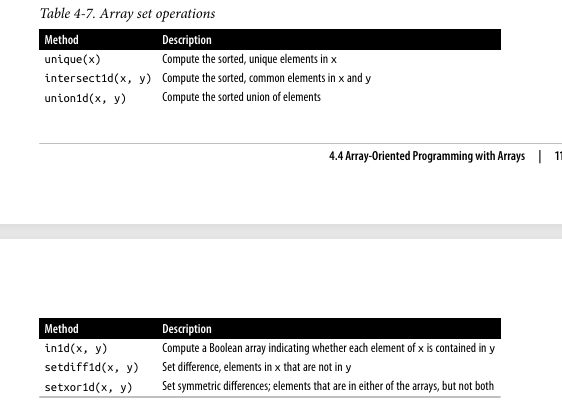